# Exploratory Data Analysis (EDA)

## Introduction

In this notebook, I will:

- Load the cleaned tweets from `data/processed/`.
- Analyze sentiment distribution (positive, negative, neutral).
- Examine brand distribution (Apple vs. Google).
- Explore tweet characteristics, such as length and common words.
- Draw insights to guide my modeling choices.

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../Twitter-Sentiment-Analysis/data/processed/cleaned_tweets.csv')

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1072 entries, 0 to 1071
Data columns (total 5 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          1072 non-null   object
 1   emotion_in_tweet_is_directed_at                     1072 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  1072 non-null   object
 3   sentiment                                           1072 non-null   object
 4   cleaned_text                                        1072 non-null   object
dtypes: object(5)
memory usage: 42.0+ KB


---

## Sentiment Distribution

I want to see how many tweets are labeled positive, negative, and neutral after filtering for Apple and Google.

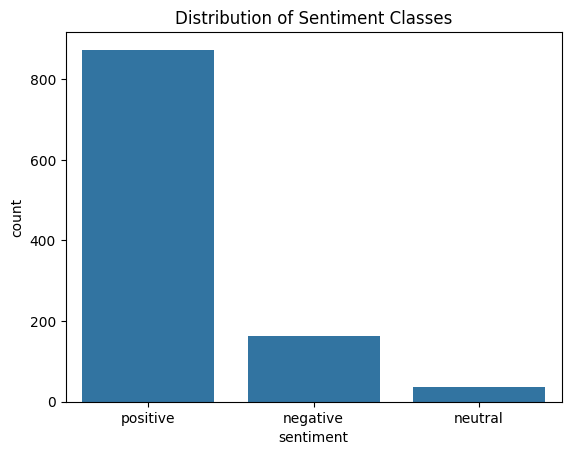

sentiment
positive    873
negative    163
neutral      36
Name: count, dtype: int64

In [2]:
sns.countplot(data=df, x='sentiment')
plt.title('Distribution of Sentiment Classes')
plt.show()

df['sentiment'].value_counts()

---

## Brand Distribution

Next, I will see how many tweets are about Apple vs. Google.

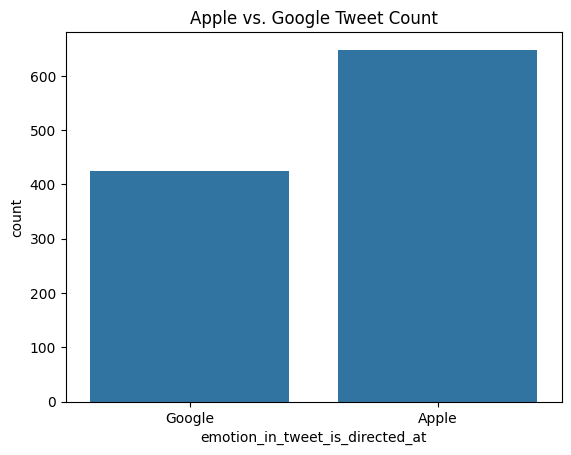

emotion_in_tweet_is_directed_at
Apple     648
Google    424
Name: count, dtype: int64

In [3]:
sns.countplot(data=df, x='emotion_in_tweet_is_directed_at')
plt.title('Apple vs. Google Tweet Count')
plt.show()

df['emotion_in_tweet_is_directed_at'].value_counts()

---

## Tweet Length Analysis

Here, I analyze how long the tweets are to see if length correlates with sentiment or brand in some way.

In [4]:
df['tweet_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))
df['tweet_length'].describe()

count    1072.000000
mean       17.142724
std         4.709404
min         5.000000
25%        13.000000
50%        18.000000
75%        21.000000
max        32.000000
Name: tweet_length, dtype: float64

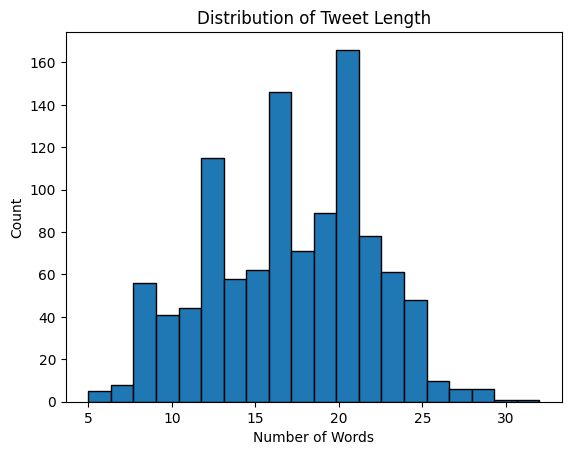

In [5]:
plt.hist(df['tweet_length'], bins=20, edgecolor='black')
plt.title('Distribution of Tweet Length')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.show()

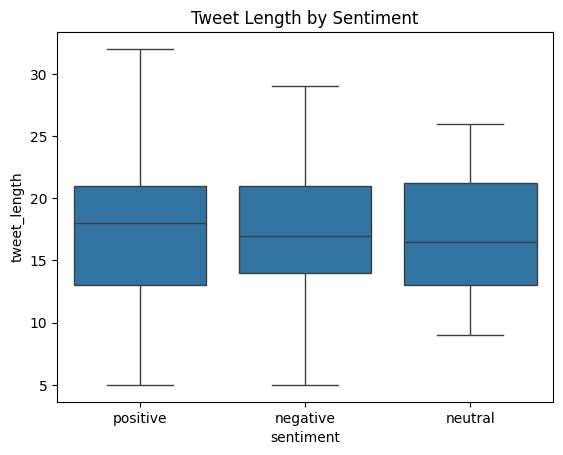

In [6]:
sns.boxplot(x='sentiment', y='tweet_length', data=df)
plt.title('Tweet Length by Sentiment')
plt.show()

---

## Common Words

Next, I will look at the most frequently used words. This might guide feature engineering in the modeling phase.

In [7]:
from collections import Counter

# Combining all tweets into a single string
all_words = ' '.join(df['cleaned_text']).split()

# Counting the most common words
counter = Counter(all_words)
common_words = counter.most_common(20)
common_words

[('sxsw', 1112),
 ('apple', 635),
 ('the', 548),
 ('link', 428),
 ('to', 391),
 ('google', 386),
 ('rt', 363),
 ('at', 362),
 ('store', 333),
 ('a', 310),
 ('in', 287),
 ('is', 276),
 ('for', 268),
 ('of', 265),
 ('and', 190),
 ('up', 161),
 ('popup', 146),
 ('austin', 142),
 ('it', 141),
 ('on', 129)]

---

## Sentiment by Brand

I want to see the distribution of positive, negative, and neutral tweets broken down by Apple or Google.

In [8]:
pd.crosstab(df['emotion_in_tweet_is_directed_at'], df['sentiment'])

sentiment,negative,neutral,positive
emotion_in_tweet_is_directed_at,,,
Apple,95,21,532
Google,68,15,341


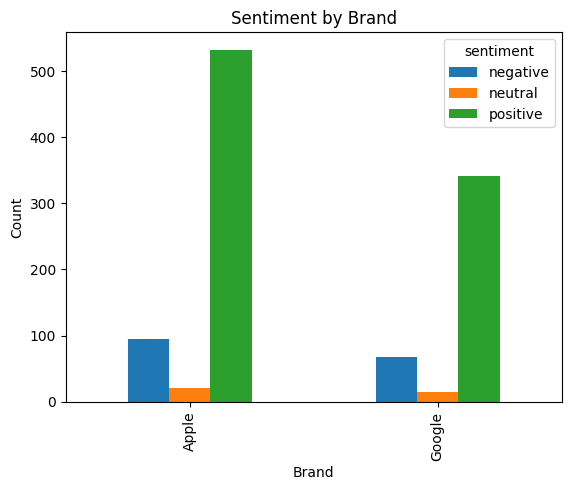

In [9]:
cross_tab = pd.crosstab(df['emotion_in_tweet_is_directed_at'], df['sentiment'])
cross_tab.plot(kind='bar', stacked=False)
plt.title('Sentiment by Brand')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.show()

In [10]:
df['sentiment'].value_counts(normalize=True) * 100

sentiment
positive    81.436567
negative    15.205224
neutral      3.358209
Name: proportion, dtype: float64

---

## Key Observations

- **Sentiment Imbalance**: Positive tweets dominate the dataset (81% positive vs. 15% negative vs. 3% neutral).
- **Brand Count**: Apple has more tweets than Google.
- **Tweet Length**: The average tweet length is around 17 words, with positive tweets slightly longer.
- **Common Words**: There doesn't seem to be a high count of common words that correlate to sentiment for Apple or Google.

These observations will guide my modeling decisions. For instance, the class imbalance (positive vs. others) may require class weighting or oversampling. Also, key words might help me create custom features if necessary.

---

## Conclusion & Next Steps

- I now have a solid understanding of the tweet distribution by sentiment and brand.
- In the next notebook (`03_modelling_and_evaluation.ipynb`), I will:
  
  - Vectorize tweets using TF-IDF (or another approach).
  - Build a baseline model (e.g., Logistic Regression).
  - Explore an advanced model (e.g., DistilBERT).
  - Compare metrics and finalize the best classifier.